# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [34]:
df = pd.read_csv("../data/states_edu.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [35]:
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)


# estimating total enrollment
df['ENROLL_ALL'] = df['ENROLL_ALL'].fillna(df["ENROLL_PREK"]+df["ENROLL_PRIMARY"]+df["ENROLL_HS"])
df["ENROLL_ALL_EST"] = df["ENROLL_ALL_EST"].fillna(df["ENROLL_ALL"])

# the other columns were unable to be estimated, so the missing data could not be dealt with that way

# we are interested in grade 8 math, and will drop
# all the rows where the 8th grade math score is missing

df.dropna(subset=['AVG_MATH_8_SCORE'], inplace=True)

df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_4,ENROLL_8,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,731634.0,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
2,1992_ARIZONA,ARIZONA,1992,673477.0,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,441490.0,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,5254844.0,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN
5,1992_COLORADO,COLORADO,1992,612635.0,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,...,50648.0,45025.0,34533.0,NaN,NaN,612635.0,221.0,272.0,217.0,NaN


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: Grade 8 Math

How many years of data are logged in our dataset? 

In [65]:
# @@@ 1
# Your Code
df["YEAR"].nunique()


13

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [69]:
# @@@ 2
# select all rows based on specific state

if (df[df["STATE"] == "MICHIGAN"]["AVG_MATH_8_SCORE"].mean() < 
    df[df["STATE"] == "OHIO"]["AVG_MATH_8_SCORE"].mean()):
    print("OHIO")
else:
    print("MICHIGAN")

OHIO


Find the average for your chosen test across all states in 2019

In [70]:
# @@@ 3

df[df["YEAR"] == 2019]["AVG_MATH_8_SCORE"].mean()

np.float64(281.2641509433962)

For each state, find a maximum value for your chosen test score

In [39]:
# @@@ 4

# group by state
by_state = df.groupby("STATE")
by_state["AVG_MATH_8_SCORE"].max()

STATE
ALABAMA                 269.0
ALASKA                  283.0
ARIZONA                 283.0
ARKANSAS                279.0
CALIFORNIA              277.0
COLORADO                292.0
CONNECTICUT             289.0
DELAWARE                284.0
DISTRICT_OF_COLUMBIA    269.0
DODEA                   293.0
FLORIDA                 281.0
GEORGIA                 281.0
HAWAII                  281.0
IDAHO                   287.0
ILLINOIS                285.0
INDIANA                 288.0
IOWA                    286.0
KANSAS                  290.0
KENTUCKY                282.0
LOUISIANA               273.0
MAINE                   289.0
MARYLAND                288.0
MASSACHUSETTS           301.0
MICHIGAN                280.0
MINNESOTA               295.0
MISSISSIPPI             274.0
MISSOURI                286.0
MONTANA                 293.0
NATIONAL                285.0
NEBRASKA                288.0
NEVADA                  278.0
NEW_HAMPSHIRE           296.0
NEW_JERSEY              296.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [40]:
# @@@ 5
# let's create a new column which represents support services expenditure per student
df["SUPPORT_SERVICES_EXPENDITURE_PER_STUDENT"] = df["SUPPORT_SERVICES_EXPENDITURE"] / df["ENROLL_ALL"]

df["TOTAL_EXPENDITURE_PER_STUDENT"] = df["TOTAL_EXPENDITURE"] / df["ENROLL_ALL"]

df["INSTRUCTION_EXPENDITURE_PER_STUDENT"] = df["INSTRUCTION_EXPENDITURE"] / df["ENROLL_ALL"]

df.columns

Index(['PRIMARY_KEY', 'STATE', 'YEAR', 'ENROLL_ALL_EST', 'TOTAL_REVENUE',
       'FEDERAL_REVENUE', 'STATE_REVENUE', 'LOCAL_REVENUE',
       'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE',
       'SUPPORT_SERVICES_EXPENDITURE', 'OTHER_EXPENDITURE',
       'CAPITAL_OUTLAY_EXPENDITURE', 'ENROLL_PREK', 'ENROLL_KINDER',
       'ENROLL_4', 'ENROLL_8', 'ENROLL_12', 'ENROLL_PRIMARY', 'ENROLL_HS',
       'ENROLL_ALL', 'AVG_MATH_4_SCORE', 'AVG_MATH_8_SCORE',
       'AVG_READING_4_SCORE', 'AVG_READING_8_SCORE',
       'SUPPORT_SERVICES_EXPENDITURE_PER_STUDENT',
       'TOTAL_EXPENDITURE_PER_STUDENT', 'INSTRUCTION_EXPENDITURE_PER_STUDENT'],
      dtype='str')

Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

TOTAL_EXPENDITURE_PER_STUDENT: a state's number of students varies, so only considering expenditure may be misleading

INSTRUCTION_EXPENDITURE_PER_STUDENT: it is also important to consider the amount of spending on instruction specifically

SUPPORT_SERVICES_EXPENDITURES_PER_STUDENT: it is also important to consider the amount of spending on support services(may help lower performing students improve)

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

Text(0, 0.5, '8th Grade Math Score')

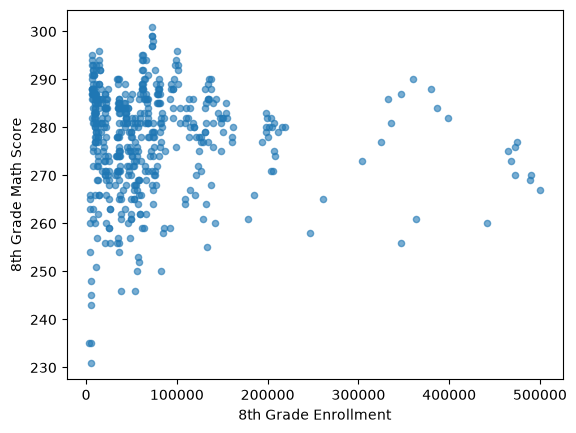

In [41]:
# @@@ 6
df.plot.scatter(x='ENROLL_8', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('8th Grade Enrollment')
plt.ylabel('8th Grade Math Score')

8th Grade Enrollment vs. 8th Grade Math Score
</p>
The relationship does not appear to be linear, with several points with 8th grade enrollment in the 200,000-500,000s not being correlated with an increase in 8th grade math score. It is difficult to determine if the relationship is positive or negative. 

**Visualization 2**

Text(0, 0.5, '8th Grade Math Score')

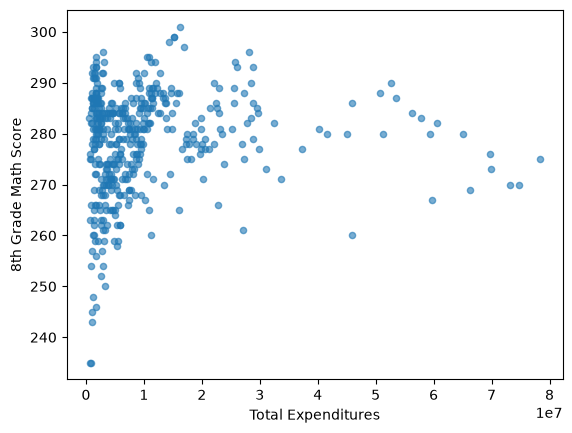

In [42]:
# @@@ 7
df.plot.scatter(x='TOTAL_EXPENDITURE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Total Expenditures')
plt.ylabel('8th Grade Math Score')

Total Expenditures vs. 8th Grade Math Score
</p>
The relationship does not appear to be linear, with several points with total expenditures in the 40 to 80 million dollars not being correlated with an increase in 8th grade math score. The shape of the data seems similar to the shape of 8th Grade Enrollment vs. 8th Grade Math Score, with many points around the lower x-values that take on lower or higher 8th grade math scores. It is difficult to determine if the relationship is positive or negative. 

**Visualization 3**

Text(0, 0.5, '8th Grade Math Score')

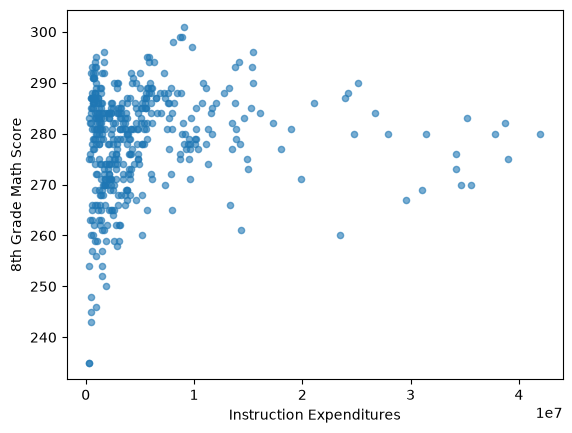

In [43]:
df.plot.scatter(x='INSTRUCTION_EXPENDITURE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Instruction Expenditures')
plt.ylabel('8th Grade Math Score')

Instruction expenditures vs. 8th Grade Math Score
</p> 
The relationship does not appear to be linear, with several points with instruction expenditures around the 15 to 40 million dollars not being correlated with an increase in 8th grade math score. The shape of the data seems similar to the shape of 8th Grade Enrollment vs. 8th Grade Math Score, with many points around the lower x-values that take on lower or higher 8th grade math scores. It is difficult to determine if the relationship is positive or negative. 

**Visualization 4**

Text(0, 0.5, '8th Grade Math Score')

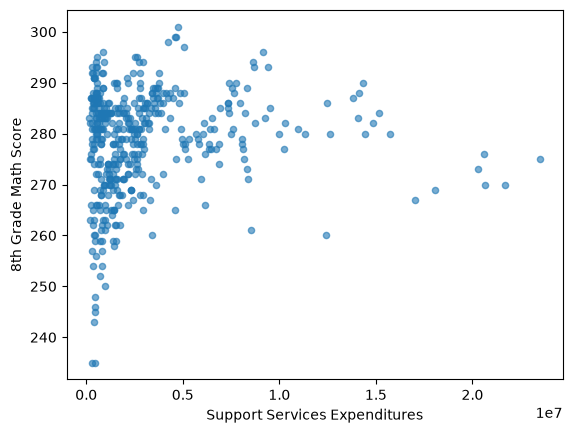

In [44]:
df.plot.scatter(x='SUPPORT_SERVICES_EXPENDITURE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Support Services Expenditures')
plt.ylabel('8th Grade Math Score')

Support Services Expenditures vs. 8th Grade Math Score
</p> 
The relationship does not appear to be linear, with several points with instruction expenditures around the 10 to 40 million dollars not being correlated with an increase in 8th grade math score. The shape of the data seems similar to the shape of 8th Grade Enrollment vs. 8th Grade Math Score, with many points around the lower x-values that take on lower or higher 8th grade math scores. 

**Visualization 5**

Text(0, 0.5, '8th Grade Math Score')

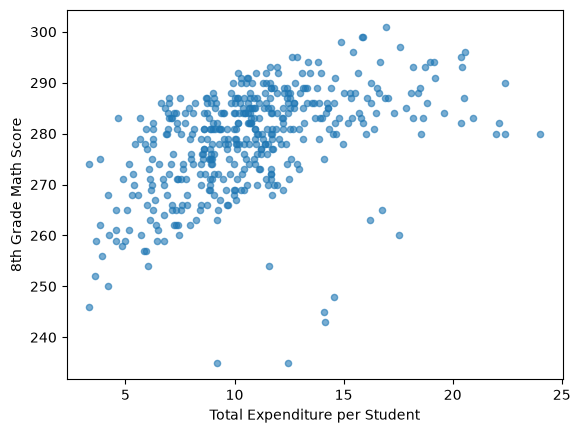

In [45]:
df.plot.scatter(x='TOTAL_EXPENDITURE_PER_STUDENT', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Total Expenditure per Student')
plt.ylabel('8th Grade Math Score')

Total Expenditure per Student vs. 8th Grade Math Score
</p> 
The relationship appears to be positive but does not appear to be linear, as while an increase in total expenditure per student is correlated with an increase in 8th grade math score, the increase in 8th grade math score seems to level off as total expenditure per student goes from 15 to 25. There are still points that do not fit that pattern.

**Visualization 6**

Text(0, 0.5, '8th Grade Math Score')

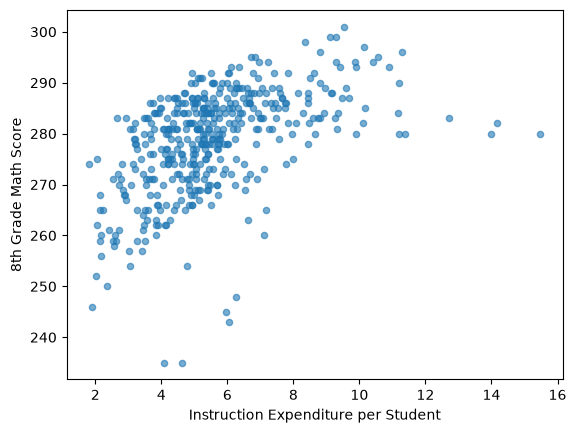

In [46]:
df.plot.scatter(x='INSTRUCTION_EXPENDITURE_PER_STUDENT', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Instruction Expenditure per Student')
plt.ylabel('8th Grade Math Score')

Instruction Expenditure per Student vs. 8th Grade Math Score
</p> 
The relationship is positive, but does not appear to be linear, as while an increase in instruction expenditure per student is correlated with an increase in 8th grade math score, the increase in 8th grade math score seems to level off as instruction expenditure per student goes from 10 to 16. There are still points that do not fit that pattern, where total expenditure per student from 10 to 16 is still associated with low 8th grade math score. 

**Visualization 7**

Text(0, 0.5, '8th Grade Math Score')

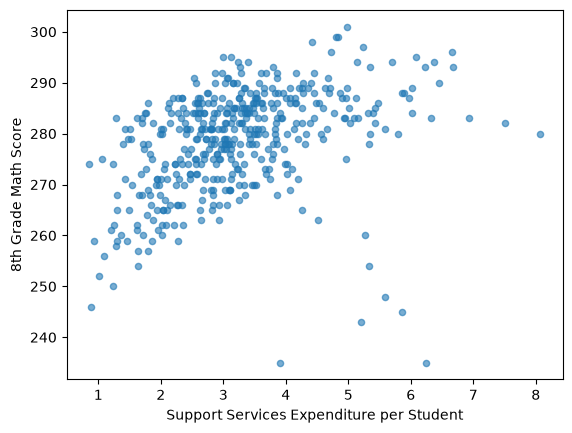

In [47]:
df.plot.scatter(x='SUPPORT_SERVICES_EXPENDITURE_PER_STUDENT', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Support Services Expenditure per Student')
plt.ylabel('8th Grade Math Score')

Support Services Expenditure per Student vs. 8th Grade Math Score
</p> 
The relationship does not appear to be linear, as while there is a positive relationship, with an increase in support services expenditure per student correlated with an increase in 8th grade math score, the increase in 8th grade math score seems to level off as support services expenditure per student goes from 6 to 8. There are still points that do not fit that pattern, where support services expenditure per student is still associated with low 8th grade math score. 

**Visualization 8**

Text(0, 0.5, '8th Grade Math Score')

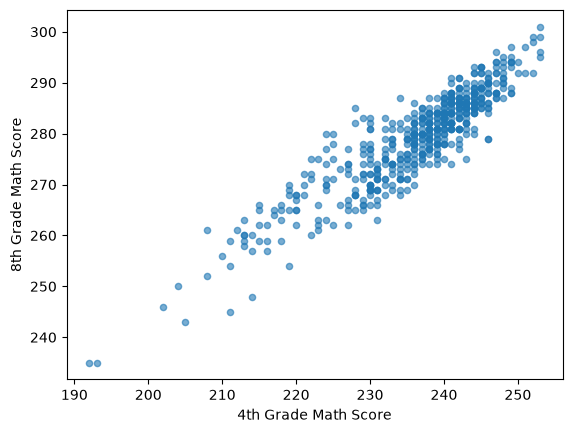

In [48]:
df.plot.scatter(x='AVG_MATH_4_SCORE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('4th Grade Math Score')
plt.ylabel('8th Grade Math Score')

4th Grade Math Score vs. 8th Grade Math Score
</p> 
The relationship appears to be moderately strong, positive, and linear. As 4th grade math score increases, there is less spread in the data. 

**Visualization 9**

Text(0, 0.5, '8th Grade Math Score')

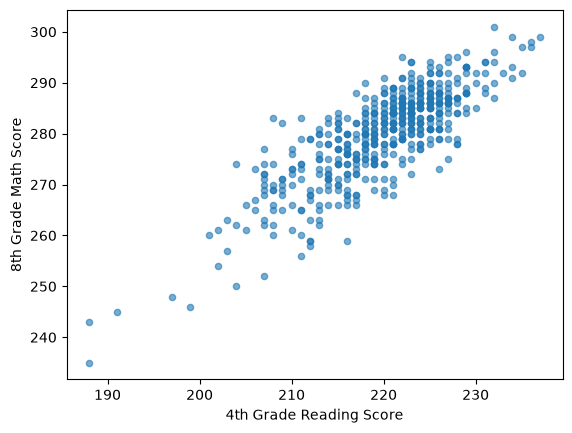

In [49]:
df.plot.scatter(x='AVG_READING_4_SCORE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('4th Grade Reading Score')
plt.ylabel('8th Grade Math Score')

4th Grade Reading Score vs. 8th Grade Math Score
</p> 
The relationship appears to be moderately strong, positive, and linear. As 4th grade reading score increases, there is less spread in the data. 

Text(0, 0.5, '8th Grade Math Score')

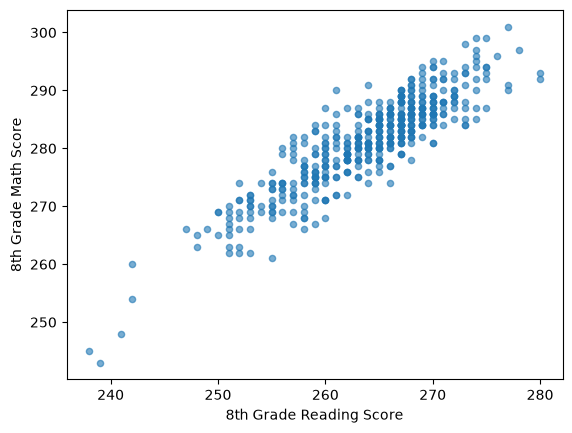

In [50]:
df.plot.scatter(x='AVG_READING_8_SCORE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('8th Grade Reading Score')
plt.ylabel('8th Grade Math Score')

8th Grade Reading Score vs. 8th Grade Math Score
</p> 
The relationship appears to be moderately strong, positive, and linear. Most of the points are clostered around a 8th Grade Reading Score of 260 to 270, and a 8th Grade Math Score of 270 to 290. 

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
# @@@ 8
# X is commonly used to denote the input data
# y is used for the response / output data
X = df[['AVG_READING_8_SCORE','AVG_MATH_4_SCORE','AVG_READING_4_SCORE']].dropna()
y = df.loc[X.index]['AVG_MATH_8_SCORE']

# We also need to make sure there is no NaN in y
# This time, we will fill the NaN with the median of y 
# We prefer median to mean because EDA reveals that the response variable is left-skewed. 
# Therefore, the mean may not represent the data very well
y.fillna(y.median(), inplace=True)


561     262.0
562     279.0
563     271.0
564     266.0
565     267.0
        ...  
1710    287.0
1711    286.0
1712    272.0
1713    289.0
1714    286.0
Name: AVG_MATH_8_SCORE, Length: 478, dtype: float64

In [53]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42)


<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [54]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [55]:
# @@@ 11
# create your model here
model = LinearRegression()

In [56]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.79, 0.85,-0.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['AVG_READING_8_SCORE','AVG_MATH_4_SCORE','AVG_READING_4_SCORE']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-43.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [57]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [58]:
# @@@ 12
# R^2 value describes how well a linear model fits the data
# It ranges between 0 and 1
# There are many caveats to R^2 but it is a good starting point
model.score(X_test, y_test)

0.9139898681580969

In [59]:
# mean absolute error
np.mean(np.abs(model.predict(X_test)-y_test))

np.float64(1.8940401296820266)

In [60]:
# mean error
np.mean(model.predict(X_test)-y_test)

np.float64(0.6212045711607241)

We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

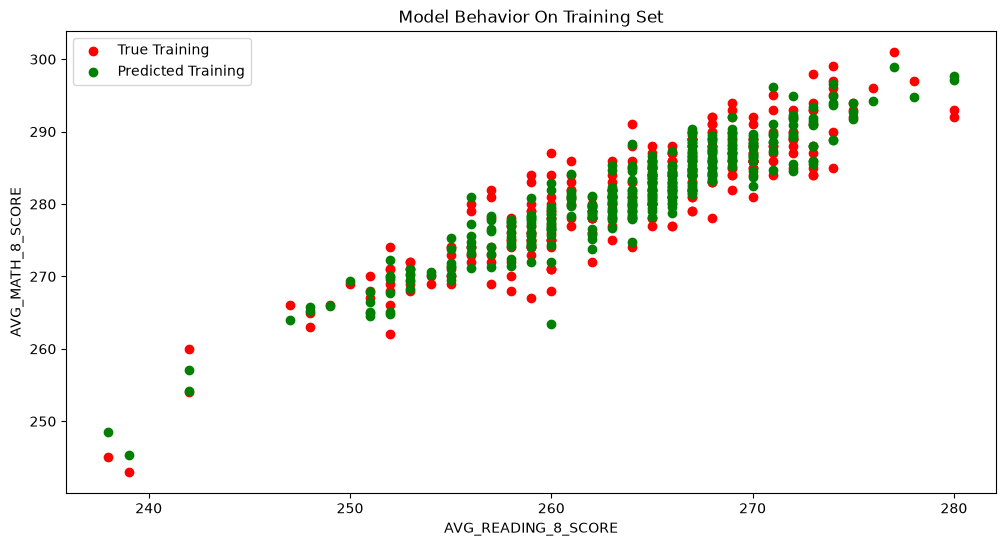

In [63]:
# @@@ 13

col_name = 'AVG_READING_8_SCORE'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('AVG_MATH_8_SCORE')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

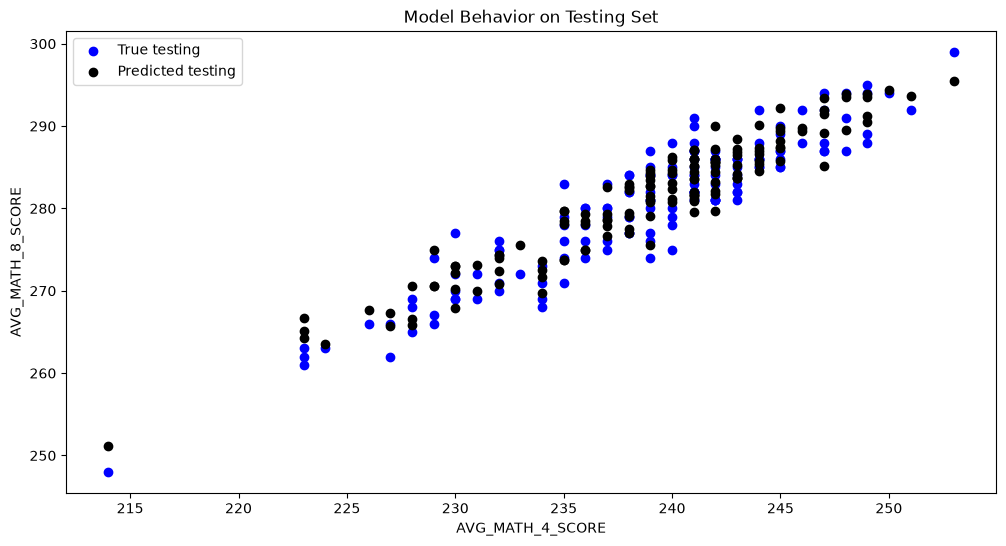

In [64]:
# @@@ 14


col_name = 'AVG_MATH_4_SCORE'

f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('AVG_MATH_8_SCORE')

plt.title("Model Behavior on Testing Set")